In [41]:
# S5A — Data assembly: simulation manifest, batch logs, EnergyPlus monthly meters.
from google.colab import drive
drive.mount('/content/drive')

import os, json, sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

BASE        = '/content/drive/MyDrive/BEM-LLM'
DATA        = f'{BASE}/data'
ANALIZ      = f'{BASE}/analiz'
SPRINT2_DIR = f'{ANALIZ}/sprint2_lobo'
PROMPTS_DIR = f'{ANALIZ}/sprint3_prompts'
SIM_DIR     = f'{ANALIZ}/sprint4_simulation'
SONUC_DIR   = f'{BASE}/sonuclar'
S5_DIR      = f'{ANALIZ}/sprint5_metrics'
FIG_DIR     = f'{S5_DIR}/figures'
os.makedirs(S5_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

with open(f'{ANALIZ}/protocol.json') as f:
    protocol = json.load(f)
with open(f'{SPRINT2_DIR}/lobo_range_table.json') as f:
    lobo = json.load(f)

TESTED_BUILDINGS = protocol['tested_buildings']
TARGET_PARAMS = lobo['target_parameters']
PHYSICAL_BOUNDS = lobo['physical_bounds']
MAIN_CLIMATE = protocol['climates']['main']
STRESS_CLIMATES = protocol['climates']['validation']
ASHRAE14_MONTHLY = {'NMBE_pct': 5.0, 'CVRMSE_pct': 15.0}  # ASHRAE Guideline 14, monthly calibration

reference_parameters = pd.read_csv(f'{SPRINT2_DIR}/reference_parameters.csv')
param_debug = pd.read_csv(f'{PROMPTS_DIR}/param_debug_mapping.csv')
ep_baselines = pd.read_csv(f'{SPRINT2_DIR}/energyplus_baseline_vectors.csv')

ref_long = (reference_parameters
            .melt(id_vars='building_type', var_name='true_name', value_name='ref_value')
            .rename(columns={'building_type': 'building'}))
ref_long = ref_long[ref_long['true_name'].isin(TARGET_PARAMS)]


def load_manifest_and_log(manifest_path, log_names):
    manifest = pd.read_csv(manifest_path)
    logs = [pd.read_csv(f'{SIM_DIR}/{n}') for n in log_names if os.path.exists(f'{SIM_DIR}/{n}')]
    log_df = pd.concat(logs, ignore_index=True) if logs else pd.DataFrame()
    manifest['tag'] = manifest.apply(lambda r: f'{r["building"]}_{r["climate"]}_{r["source"]}', axis=1)
    return manifest.merge(log_df[['tag', 'round_trip_ok', 'energyplus_ok', 'duration_s']], on='tag', how='left')


main_df = load_manifest_and_log(f'{SIM_DIR}/simulation_vector_manifest.csv', ['full_batch_log_5A.csv'])
stress_df = load_manifest_and_log(f'{SIM_DIR}/simulation_vector_manifest_weather_stress.csv',
                                   ['full_batch_log_1A.csv', 'full_batch_log_7.csv'])
all_vectors = pd.concat([main_df, stress_df], ignore_index=True)
successful = all_vectors[all_vectors.energyplus_ok == True]
print(f'{len(all_vectors)} total vectors, {len(successful)} EnergyPlus-successful')


def read_monthly_meters(tag):
    """Return (electricity_12, gas_12) monthly totals [J], or (None, None)."""
    path = f'{SONUC_DIR}/{tag}/eplusmtr.csv'
    if not os.path.exists(path):
        return None, None
    try:
        df = pd.read_csv(path)
    except Exception:
        return None, None
    df.columns = [c.strip() for c in df.columns]

    def monthly_col(meter):
        exact = f'{meter} [J](Monthly)'
        if exact in df.columns:
            return exact
        cands = [c for c in df.columns if meter in c and '(Monthly)' in c]
        return cands[0] if cands else None

    elec_col, gas_col = monthly_col('Electricity:Facility'), monthly_col('NaturalGas:Facility')
    if elec_col is None:
        return None, None
    elec = pd.to_numeric(df[elec_col], errors='coerce').dropna().values
    if len(elec) < 12:
        return None, None
    elec = elec[:12]
    if gas_col is not None:
        gas_raw = pd.to_numeric(df[gas_col], errors='coerce').dropna().values
        gas = gas_raw[:12] if len(gas_raw) >= 12 else np.zeros(12)
    else:
        gas = np.zeros(12)
    return elec, gas


monthly_data, monthly_total_data = {}, {}  # electricity-only (K1/K2); electricity+gas (K3/EYA)
for _, row in successful.iterrows():
    elec, gas = read_monthly_meters(row['tag'])
    if elec is not None:
        monthly_data[row['tag']] = elec
        monthly_total_data[row['tag']] = elec + gas
print(f'{len(monthly_data)}/{len(successful)} meter files parsed to 12 monthly values.')

doe_ref_tags, doe_ref_total_tags = {}, {}
for _, row in successful[successful.source == 'DOE_reference'].iterrows():
    if row['tag'] in monthly_data:
        doe_ref_tags[(row['building'], row['climate'])] = monthly_data[row['tag']]
        doe_ref_total_tags[(row['building'], row['climate'])] = monthly_total_data[row['tag']]
doe_ref_climates = sorted(set(c for _, c in doe_ref_tags))
assert set(doe_ref_climates) == {MAIN_CLIMATE}, 'Unexpected DOE reference climate(s).'
print(f'DOE reference available at climates: {doe_ref_climates}')

all_vectors.to_csv(f'{S5_DIR}/all_vectors.csv', index=False)
with open(f'{S5_DIR}/monthly_electricity.json', 'w') as f:
    json.dump({k: v.tolist() for k, v in monthly_data.items()}, f)
with open(f'{S5_DIR}/monthly_total_energy.json', 'w') as f:
    json.dump({k: v.tolist() for k, v in monthly_total_data.items()}, f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
360 total vectors, 333 EnergyPlus-successful
333/333 meter files parsed to 12 monthly values.
DOE reference available at climates: ['5A']


           mean  median
format                 
F1      1832.53   83.58
F2        73.86   20.78
F3        67.85   15.26
F4        59.40   15.16
                                   mean  median
format model                                   
F1     llama-3.3-70b-versatile   663.94  189.55
       openai/gpt-oss-120b      3001.11   28.79
F2     llama-3.3-70b-versatile    47.66   19.34
       openai/gpt-oss-120b       100.06   20.93
F3     llama-3.3-70b-versatile    58.53   12.55
       openai/gpt-oss-120b        77.16   19.26
F4     llama-3.3-70b-versatile    46.06   14.13
       openai/gpt-oss-120b        72.75   18.45


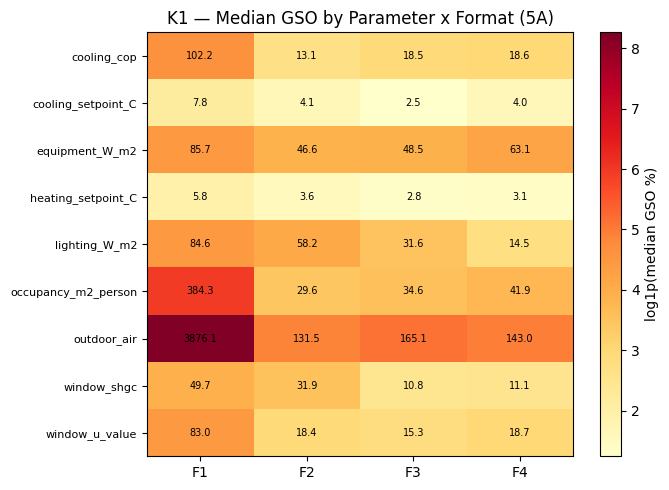

In [42]:
# S5B — K1: Gross Standardized Offset (GSO), main climate, parameter level.
llm_params = param_debug[param_debug['format'].isin(['F1', 'F2', 'F3', 'F4'])].copy()
llm_params_main = llm_params[llm_params['climate'] == MAIN_CLIMATE]

gso_df = llm_params_main.merge(ref_long, on=['building', 'true_name'], how='left')
gso_df['gso_pct'] = (gso_df['value'] - gso_df['ref_value']).abs() / gso_df['ref_value'].abs() * 100
gso_df.to_csv(f'{S5_DIR}/K1_gso.csv', index=False)

print(gso_df.groupby('format')['gso_pct'].agg(['mean', 'median']).round(2).to_string())
print(gso_df.groupby(['format', 'model'])['gso_pct'].agg(['mean', 'median']).round(2).to_string())

pivot = gso_df.groupby(['true_name', 'format'])['gso_pct'].median().unstack().reindex(columns=['F1', 'F2', 'F3', 'F4'])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(np.log1p(pivot), cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot))); ax.set_yticklabels(pivot.index, fontsize=8)
for i in range(len(pivot)):
    for j in range(4):
        v = pivot.iloc[i, j]
        ax.text(j, i, f'{v:.1f}' if pd.notna(v) else '-', ha='center', va='center', fontsize=7)
plt.colorbar(im, label='log1p(median GSO %)')
plt.title('K1 — Median GSO by Parameter x Format (5A)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/K1_gso_heatmap.png', dpi=200)
plt.show()

K2: 208 vectors, climates present: ['5A']
                                cvrmse_pct  nmbe_pct
format model                                        
F1     llama-3.3-70b-versatile       15.44    -14.49
       openai/gpt-oss-120b         1074.00   1030.84
F2     llama-3.3-70b-versatile       27.65     -1.02
       openai/gpt-oss-120b           32.98      8.78
F3     llama-3.3-70b-versatile       37.84    -27.81
       openai/gpt-oss-120b           28.84     -9.67
F4     llama-3.3-70b-versatile       27.93    -16.76
       openai/gpt-oss-120b           26.66     -7.22
format
F1     0.0
F2     2.1
F3    14.0
F4    18.4


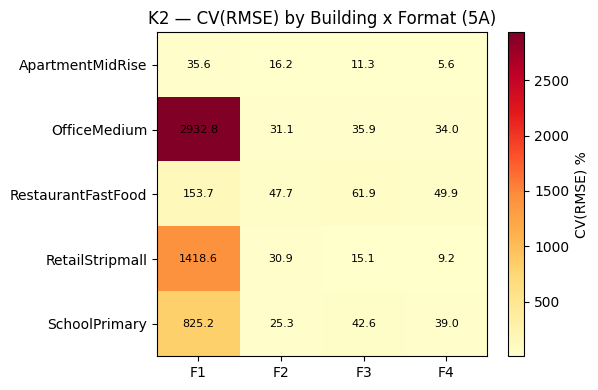

In [43]:
# S5C — K2: CV(RMSE) / NMBE vs. DOE reference, monthly resolution, electricity meter.
cvrmse_rows = []
for _, row in successful.iterrows():
    tag = row['tag']
    if tag not in monthly_data or row['source'] == 'DOE_reference':
        continue
    key = (row['building'], row['climate'])
    if key not in doe_ref_tags:
        continue
    y, yhat = doe_ref_tags[key].astype(float), monthly_data[tag].astype(float)
    if len(y) != len(yhat) or y.mean() == 0:
        continue
    rmse = np.sqrt(np.mean((y - yhat) ** 2))
    cvrmse_rows.append({
        'tag': tag, 'building': row['building'], 'climate': row['climate'],
        'source': row['source'], 'source_type': row['source_type'],
        'format': row.get('format'), 'model': row.get('model'), 'seed': row.get('seed'),
        'cvrmse_pct': rmse / y.mean() * 100,
        'nmbe_pct': np.sum(yhat - y) / (len(y) * y.mean()) * 100,
    })

cvrmse_df = pd.DataFrame(cvrmse_rows)
cvrmse_df['ashrae14_pass'] = (
    (cvrmse_df['cvrmse_pct'] <= ASHRAE14_MONTHLY['CVRMSE_pct']) &
    (cvrmse_df['nmbe_pct'].abs() <= ASHRAE14_MONTHLY['NMBE_pct'])
)
cvrmse_df.to_csv(f'{S5_DIR}/K2_cvrmse_nmbe.csv', index=False)

llm_cvrmse_main = cvrmse_df[(cvrmse_df.source_type == 'llm') & (cvrmse_df.climate == MAIN_CLIMATE)]
print(f'K2: {len(cvrmse_df)} vectors, climates present: {sorted(cvrmse_df.climate.unique())}')
print(llm_cvrmse_main.groupby(['format', 'model'])[['cvrmse_pct', 'nmbe_pct']].mean().round(2).to_string())
print(llm_cvrmse_main.groupby('format')['ashrae14_pass'].mean().mul(100).round(1).to_string())

pivot2 = llm_cvrmse_main.groupby(['building', 'format'])['cvrmse_pct'].mean().unstack().reindex(columns=['F1', 'F2', 'F3', 'F4'])
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot2, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(pivot2.columns)
ax.set_yticks(range(len(pivot2))); ax.set_yticklabels(pivot2.index)
for i in range(len(pivot2)):
    for j in range(4):
        v = pivot2.iloc[i, j]
        ax.text(j, i, f'{v:.1f}' if pd.notna(v) else '-', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='CV(RMSE) %')
plt.title('K2 — CV(RMSE) by Building x Format (5A)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/K2_cvrmse_heatmap.png', dpi=200)
plt.show()

K3 EYA (5A): 15/208 anomalies
        sum   mean
format            
F1       12  0.462
F2        0  0.000
F3        0  0.000
F4        0  0.000
K3 PFI (all climates): 48/2700 violations
        sum   mean
format            
F1       48  0.107
F2        0  0.000
F3        0  0.000
F4        0  0.000


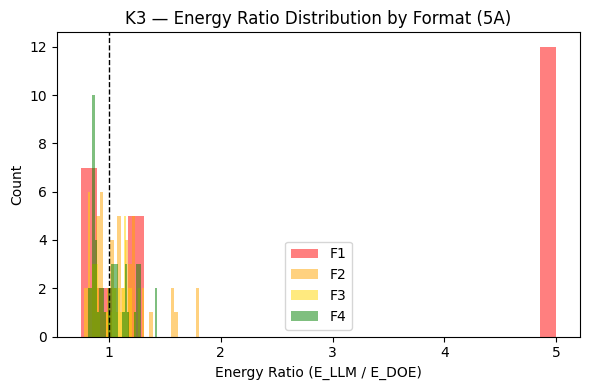

In [44]:
# S5D — K3: Energy Yield Anomaly (EYA, total energy) and Parameter Feasibility
# Index (PFI, physical-bound violations with basis/source per parameter).
eya_rows = []
for _, row in successful.iterrows():
    tag = row['tag']
    if tag not in monthly_total_data or row['source'] == 'DOE_reference':
        continue
    key = (row['building'], row['climate'])
    if key not in doe_ref_total_tags:
        continue
    e_llm, e_doe = monthly_total_data[tag].astype(float).sum(), doe_ref_total_tags[key].astype(float).sum()
    if e_doe == 0:
        continue
    ratio = e_llm / e_doe
    eya_rows.append({
        'tag': tag, 'building': row['building'], 'climate': row['climate'],
        'source': row['source'], 'source_type': row['source_type'],
        'format': row.get('format'), 'model': row.get('model'), 'seed': row.get('seed'),
        'energy_ratio': ratio, 'anomaly': (ratio < 0.5) or (ratio > 2.0),
    })
eya_df = pd.DataFrame(eya_rows)
eya_df.to_csv(f'{S5_DIR}/K3_eya.csv', index=False)
eya_main = eya_df[eya_df.climate == MAIN_CLIMATE]

# Bound basis: physical realizability (non-negativity, 0-1 fraction, thermostat
# safety range) rather than ASHRAE 90.1 equipment-minimum-efficiency thresholds.
PFI_BOUND_BASIS = {
    'window_u_value':      ('physical: cannot be negative', 'not enforced'),
    'window_shgc':          ('physical: 0-1 fraction of incident solar radiation', 'physical: cannot exceed 1.0'),
    'lighting_W_m2':        ('physical: cannot be negative', 'not enforced'),
    'equipment_W_m2':       ('physical: cannot be negative', 'not enforced'),
    'occupancy_m2_person':  ('physical: cannot be negative', 'not enforced'),
    'outdoor_air':          ('physical: cannot be negative', 'not enforced'),
    'cooling_cop':          ('physical: cannot be negative/zero (not an ASHRAE 90.1 Table 6.8.1 minimum)', 'not enforced'),
    'heating_setpoint_C':   ('practical range, ASHRAE 55 comfort band + margin', 'practical range, ASHRAE 55 comfort band + margin'),
    'cooling_setpoint_C':   ('practical range, ASHRAE 55 comfort band + margin', 'practical range, ASHRAE 55 comfort band + margin'),
}

pfi_rows = []
for _, r in llm_params.iterrows():
    lo, hi = PHYSICAL_BOUNDS.get(r['true_name'], (None, None))
    violated = (lo is not None and r['value'] < lo) or (hi is not None and r['value'] > hi)
    lo_basis, hi_basis = PFI_BOUND_BASIS.get(r['true_name'], (None, None))
    pfi_rows.append({**r.to_dict(), 'lo_bound': lo, 'hi_bound': hi, 'bound_violated': violated,
                      'lo_basis': lo_basis, 'hi_basis': hi_basis})
pfi_df = pd.DataFrame(pfi_rows)
pfi_df.to_csv(f'{S5_DIR}/K3_pfi.csv', index=False)

print(f'K3 EYA (5A): {eya_main.anomaly.sum()}/{len(eya_main)} anomalies')
print(eya_main[eya_main.source_type == 'llm'].groupby('format')['anomaly'].agg(['sum', 'mean']).round(3).to_string())
print(f'K3 PFI (all climates): {pfi_df.bound_violated.sum()}/{len(pfi_df)} violations')
print(pfi_df[pfi_df.format.notna()].groupby('format')['bound_violated'].agg(['sum', 'mean']).round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
for fmt, color in zip(['F1', 'F2', 'F3', 'F4'], ['red', 'orange', 'gold', 'green']):
    d = eya_main[eya_main.format == fmt]['energy_ratio'].dropna()
    if len(d):
        ax.hist(np.clip(d, 0, 5), bins=30, alpha=0.5, label=fmt, color=color)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Energy Ratio (E_LLM / E_DOE)'); ax.set_ylabel('Count')
ax.legend(); plt.title('K3 — Energy Ratio Distribution by Format (5A)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/K3_eya_distribution.png', dpi=200)
plt.show()

Shapiro-Wilk on residuals: W=0.940, p=0.0000
                    sum_sq     df        F  PR(>F)  eta_sq
C(Unit)            29.4969    1.0  34.2776  0.0000  0.0971
C(Range)           39.9683    1.0  46.4462  0.0000  0.1315
C(building)        69.4277    4.0  20.1701  0.0000  0.2285
C(model)            0.0877    1.0   0.1019  0.7499  0.0003
C(Unit):C(Range)   23.7276    1.0  27.5732  0.0000  0.0781
Residual          141.1267  164.0      NaN     NaN  0.4645
F1-excluded sensitivity check (Model term only comparable to full model):
                   sum_sq     df        F  PR(>F)  eta_sq
C(Unit)           26.0651    1.0  68.8793  0.0000  0.1396
C(Range)          16.2122    1.0  42.8422  0.0000  0.0868
C(building)       65.4905    4.0  43.2661  0.0000  0.3507
C(model)           0.0089    1.0   0.0235  0.8785  0.0000
C(Unit):C(Range)  26.3823    1.0  69.7175  0.0000  0.1413
Residual          52.6000  139.0      NaN     NaN  0.2816


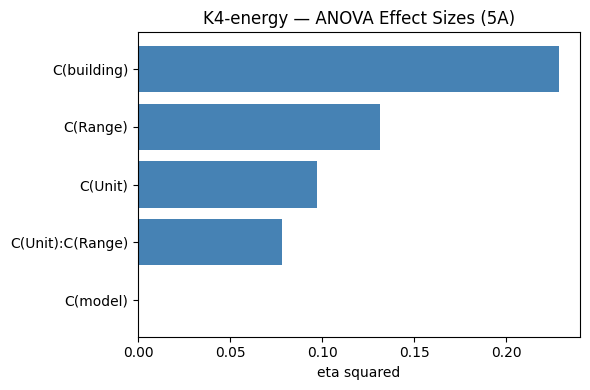

In [45]:
# S5E — K4-energy: log(1+CVRMSE) ~ Unit*Range + Building + Model. One
# observation per (building, format, model, seed); fixed-effects OLS
# (a random-intercept model would be degenerate at 1 obs/group).
# Also reports the same model on the F1-excluded subset, to confirm the
# null Model effect does not depend on F1's imbalanced cell sizes.
model_df = llm_cvrmse_main.copy()
model_df['Unit'] = model_df['format'].isin(['F2', 'F4']).astype(int)
model_df['Range'] = model_df['format'].isin(['F3', 'F4']).astype(int)
model_df['log_cvrmse'] = np.log1p(model_df['cvrmse_pct'])
assert model_df.groupby(['building', 'format', 'model', 'seed']).size().max() == 1

ols_model = smf.ols('log_cvrmse ~ C(Unit)*C(Range) + C(building) + C(model)', data=model_df).fit()
anova_table = anova_lm(ols_model, typ=2)
anova_table['eta_sq'] = anova_table['sum_sq'] / anova_table['sum_sq'].sum()
anova_table.to_csv(f'{S5_DIR}/K4_anova.csv')
with open(f'{S5_DIR}/K4_ols_summary.txt', 'w') as f:
    f.write(str(ols_model.summary()))

sw_resid = stats.shapiro(ols_model.resid)
print(f'Shapiro-Wilk on residuals: W={sw_resid.statistic:.3f}, p={sw_resid.pvalue:.4f}')
print(anova_table.round(4).to_string())

model_df_no_f1 = model_df[model_df['format'] != 'F1'].copy()
ols_no_f1 = smf.ols('log_cvrmse ~ C(Unit)*C(Range) + C(building) + C(model)', data=model_df_no_f1).fit()
anova_no_f1 = anova_lm(ols_no_f1, typ=2)
anova_no_f1['eta_sq'] = anova_no_f1['sum_sq'] / anova_no_f1['sum_sq'].sum()
anova_no_f1.to_csv(f'{S5_DIR}/K4_anova_sensitivity_no_F1.csv')
print('F1-excluded sensitivity check (Model term only comparable to full model):')
print(anova_no_f1.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
eta = anova_table['eta_sq'].drop('Residual', errors='ignore').sort_values()
ax.barh(eta.index, eta.values, color='steelblue')
ax.set_xlabel('eta squared'); plt.title('K4-energy — ANOVA Effect Sizes (5A)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/K4_anova_eta2.png', dpi=200)
plt.show()

Shapiro-Wilk on residuals: W=0.969, p=0.0000
                     sum_sq      df         F  PR(>F)  eta_sq
C(Unit)            188.2896     1.0  131.5672  0.0000  0.0347
C(Range)           275.5754     1.0  192.5581  0.0000  0.0508
C(building)          8.8082     4.0    1.5387  0.1884  0.0016
C(true_name)      2230.6815     8.0  194.8358  0.0000  0.4112
C(Unit):C(Range)   168.2903     1.0  117.5927  0.0000  0.0310
Residual          2553.1339  1784.0       NaN     NaN  0.4706
Model-inclusive variant:
                     sum_sq      df         F  PR(>F)  eta_sq
C(Unit)            188.2896     1.0  134.1178  0.0000  0.0347
C(Range)           275.5754     1.0  196.2911  0.0000  0.0508
C(building)          8.8082     4.0    1.5685  0.1801  0.0016
C(true_name)      2230.6815     8.0  198.6130  0.0000  0.4112
C(model)            49.9593     1.0   35.5858  0.0000  0.0092
C(Unit):C(Range)   168.2903     1.0  119.8724  0.0000  0.0310
Residual          2503.1746  1783.0       NaN     NaN  0.4614


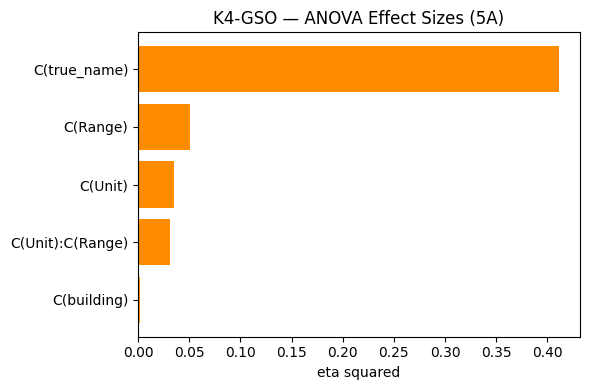

In [46]:
# S5F — K4-GSO: log(1+GSO) ~ Unit*Range + Building + Parameter (per-parameter
# observations, main climate). Primary formula omits Model to match the
# requested specification exactly; a model-inclusive variant is reported
# alongside for completeness.
gso_model_df = gso_df.copy()
gso_model_df['Unit'] = gso_model_df['format'].isin(['F2', 'F4']).astype(int)
gso_model_df['Range'] = gso_model_df['format'].isin(['F3', 'F4']).astype(int)
gso_model_df['log_gso'] = np.log1p(gso_model_df['gso_pct'])

ols_gso = smf.ols('log_gso ~ C(Unit)*C(Range) + C(building) + C(true_name)', data=gso_model_df).fit()
anova_gso_table = anova_lm(ols_gso, typ=2)
anova_gso_table['eta_sq'] = anova_gso_table['sum_sq'] / anova_gso_table['sum_sq'].sum()
anova_gso_table.to_csv(f'{S5_DIR}/K4_anova_gso.csv')
with open(f'{S5_DIR}/K4_gso_ols_summary.txt', 'w') as f:
    f.write(str(ols_gso.summary()))

sw_resid_gso = stats.shapiro(ols_gso.resid)
print(f'Shapiro-Wilk on residuals: W={sw_resid_gso.statistic:.3f}, p={sw_resid_gso.pvalue:.4f}')
print(anova_gso_table.round(4).to_string())

ols_gso_model = smf.ols('log_gso ~ C(Unit)*C(Range) + C(building) + C(true_name) + C(model)', data=gso_model_df).fit()
anova_gso_model = anova_lm(ols_gso_model, typ=2)
anova_gso_model['eta_sq'] = anova_gso_model['sum_sq'] / anova_gso_model['sum_sq'].sum()
anova_gso_model.to_csv(f'{S5_DIR}/K4_anova_gso_with_model.csv')
print('Model-inclusive variant:')
print(anova_gso_model.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
eta_gso = anova_gso_table['eta_sq'].drop('Residual', errors='ignore').sort_values()
ax.barh(eta_gso.index, eta_gso.values, color='darkorange')
ax.set_xlabel('eta squared'); plt.title('K4-GSO — ANOVA Effect Sizes (5A)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/K4_gso_anova_eta2.png', dpi=200)
plt.show()

In [47]:
# S5G — Baseline comparison, GSO and energy level. range_midpoint is
# computed analytically from lobo['range_table'] (no EnergyPlus run) and
# therefore appears only in the GSO table.
baseline_gso = ep_baselines.melt(id_vars=['building', 'baseline_type'], value_vars=TARGET_PARAMS,
                                  var_name='true_name', value_name='value')
baseline_gso = baseline_gso.merge(ref_long, on=['building', 'true_name'], how='left')
baseline_gso['gso_pct'] = (baseline_gso['value'] - baseline_gso['ref_value']).abs() / baseline_gso['ref_value'].abs() * 100

ur_long = all_vectors[(all_vectors.source_type == 'uniform_random') & (all_vectors.climate == MAIN_CLIMATE)].melt(
    id_vars=['building', 'climate', 'source'], value_vars=TARGET_PARAMS, var_name='true_name', value_name='value')
ur_long = ur_long.merge(ref_long, on=['building', 'true_name'], how='left')
ur_long['gso_pct'] = (ur_long['value'] - ur_long['ref_value']).abs() / ur_long['ref_value'].abs() * 100

midpoint_rows_baseline = [{'building': b, 'true_name': p, 'value': sum(lobo['range_table'][b][p]) / 2}
                           for b in TESTED_BUILDINGS for p in TARGET_PARAMS]
midpoint_baseline_df = pd.DataFrame(midpoint_rows_baseline).merge(ref_long, on=['building', 'true_name'], how='left')
midpoint_baseline_df['gso_pct'] = (midpoint_baseline_df['value'] - midpoint_baseline_df['ref_value']).abs() / midpoint_baseline_df['ref_value'].abs() * 100

comparison_rows = [{'method': fmt, 'type': 'llm', **gso_df[gso_df.format == fmt]['gso_pct'].agg(['mean', 'median']).to_dict()}
                    for fmt in ['F1', 'F2', 'F3', 'F4']]
comparison_rows += [{'method': bt, 'type': 'baseline', **g['gso_pct'].agg(['mean', 'median']).to_dict()}
                     for bt, g in baseline_gso.groupby('baseline_type')]
comparison_rows += [{'method': 'uniform_random', 'type': 'baseline', **ur_long['gso_pct'].agg(['mean', 'median']).to_dict()}]
comparison_rows += [{'method': 'range_midpoint', 'type': 'baseline (analytic)',
                      **midpoint_baseline_df['gso_pct'].agg(['mean', 'median']).to_dict()}]
baseline_comparison_df = pd.DataFrame(comparison_rows).sort_values('median')
baseline_comparison_df.to_csv(f'{S5_DIR}/baseline_comparison_gso.csv', index=False)
print(baseline_comparison_df.round(2).to_string(index=False))

baseline_energy_main = cvrmse_df[
    cvrmse_df.source_type.isin(['deterministic_baseline', 'uniform_random']) & (cvrmse_df.climate == MAIN_CLIMATE)
].copy()
baseline_energy_main['group_label'] = np.where(
    baseline_energy_main['source_type'] == 'uniform_random', 'uniform_random', baseline_energy_main['source'])
energy_comparison = pd.concat([
    llm_cvrmse_main.groupby('format')[['cvrmse_pct', 'nmbe_pct']].mean().assign(type='llm'),
    baseline_energy_main.groupby('group_label')[['cvrmse_pct', 'nmbe_pct']].mean().assign(type='baseline'),
])
energy_comparison.to_csv(f'{S5_DIR}/baseline_comparison_energy.csv')
print(energy_comparison.round(2).to_string())

         method                type    mean  median
lobo_median_loo            baseline   38.56    4.68
global_constant            baseline   32.59    5.55
             F4                 llm   59.40   15.16
             F3                 llm   67.85   15.26
             F2                 llm   73.86   20.78
 range_midpoint baseline (analytic)  101.44   31.00
 uniform_random            baseline  111.79   31.11
             F1                 llm 1832.53   83.58
                 cvrmse_pct  nmbe_pct      type
F1                  1033.28    990.64       llm
F2                    30.43      4.08       llm
F3                    33.34    -18.74       llm
F4                    27.31    -12.09       llm
global_constant       31.29     10.26  baseline
lobo_median_loo       32.96      8.20  baseline
uniform_random        82.71     55.00  baseline


In [48]:
# S5H — Environment record, Sprint 5 core (S5A-G).
summary = {
    'sprint': 'Sprint 5 core: K1-K3, K4-energy, K4-GSO, baseline comparison',
    'python_version': sys.version, 'platform': platform.platform(),
    'ashrae14_threshold': ASHRAE14_MONTHLY,
    'main_climate': MAIN_CLIMATE, 'stress_climates': STRESS_CLIMATES,
    'n_gso_rows_main': len(gso_df), 'n_cvrmse_rows_main': len(llm_cvrmse_main),
    'n_eya_rows_main': len(eya_main), 'n_pfi_rows_all_climates': len(pfi_df),
    'doe_reference_available_at': doe_ref_climates,
    'k3_eya_energy_basis': 'total (electricity + gas)',
    'k2_cvrmse_energy_basis': 'electricity only (ASHRAE-14 electric-meter definition)',
    'k4_gso_formula': 'log(1+GSO) ~ Unit*Range + Building + Parameter',
    'k4_energy_formula': 'log(1+CVRMSE) ~ Unit*Range + Building + Model',
}
with open(f'{DATA}/environment_sprint5.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))

{
  "sprint": "Sprint 5 core: K1-K3, K4-energy, K4-GSO, baseline comparison",
  "python_version": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "ashrae14_threshold": {
    "NMBE_pct": 5.0,
    "CVRMSE_pct": 15.0
  },
  "main_climate": "5A",
  "stress_climates": [
    "1A",
    "7"
  ],
  "n_gso_rows_main": 1800,
  "n_cvrmse_rows_main": 173,
  "n_eya_rows_main": 208,
  "n_pfi_rows_all_climates": 2700,
  "doe_reference_available_at": [
    "5A"
  ],
  "k3_eya_energy_basis": "total (electricity + gas)",
  "k2_cvrmse_energy_basis": "electricity only (ASHRAE-14 electric-meter definition)",
  "k4_gso_formula": "log(1+GSO) ~ Unit*Range + Building + Parameter",
  "k4_energy_formula": "log(1+CVRMSE) ~ Unit*Range + Building + Model"
}


STI (GSO): 135/360 stable
STI (CV-RMSE): 4/33 stable


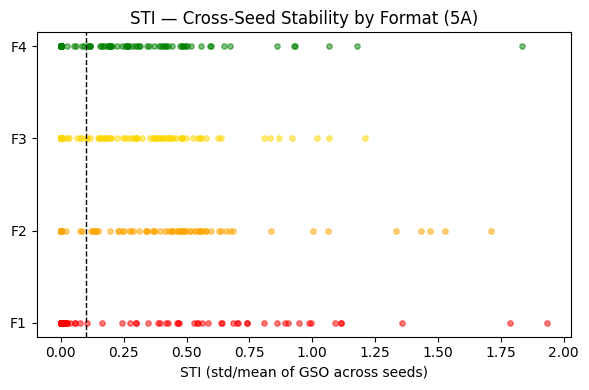

In [49]:
# S5I — Stochasticity Index (STI): cross-seed std/mean of GSO / CV(RMSE).
sti_gso = (gso_df.groupby(['building', 'format', 'model', 'true_name'])['gso_pct']
           .agg(mean='mean', std='std', n='count'))
sti_gso['sti'] = sti_gso['std'] / sti_gso['mean']
sti_gso['stable'] = np.where(sti_gso['n'] < 5, None, sti_gso['sti'] < 0.10)
sti_gso.to_csv(f'{S5_DIR}/STI_gso.csv')

sti_cvrmse = (llm_cvrmse_main.groupby(['building', 'format', 'model'])['cvrmse_pct']
              .agg(mean='mean', std='std', n='count'))
sti_cvrmse['sti'] = sti_cvrmse['std'] / sti_cvrmse['mean']
sti_cvrmse['stable'] = np.where(sti_cvrmse['n'] < 5, None, sti_cvrmse['sti'] < 0.10)
sti_cvrmse.to_csv(f'{S5_DIR}/STI_cvrmse.csv')

print(f'STI (GSO): {(sti_gso.stable == True).sum()}/{sti_gso.stable.notna().sum()} stable')
print(f'STI (CV-RMSE): {(sti_cvrmse.stable == True).sum()}/{sti_cvrmse.stable.notna().sum()} stable')

fig, ax = plt.subplots(figsize=(6, 4))
for fmt, color in zip(['F1', 'F2', 'F3', 'F4'], ['red', 'orange', 'gold', 'green']):
    d = sti_gso.reset_index()
    d = d[(d.format == fmt) & d.sti.notna()]['sti']
    ax.scatter(d, [fmt] * len(d), color=color, alpha=0.5, s=15)
ax.axvline(0.10, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('STI (std/mean of GSO across seeds)')
plt.title('STI — Cross-Seed Stability by Format (5A)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/STI_dotplot.png', dpi=200)
plt.show()

format
F3    50.9
F4    58.9


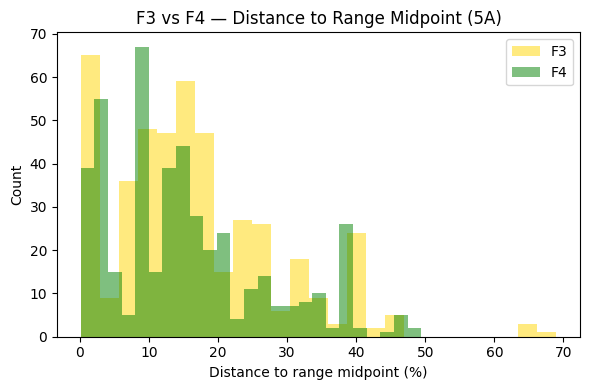

In [50]:
# S5J — Midpoint stickiness and triple-distance analysis (F3/F4 only).
# lobo_median is read from the simulated lobo_median_loo baseline (15-
# building pool) rather than recomputed, to match the pool used by F3/F4.
lobo_median_rows = ep_baselines[ep_baselines.baseline_type == 'lobo_median_loo']
lobo_median = {(row['building'], p): row[p] for _, row in lobo_median_rows.iterrows() for p in TARGET_PARAMS}

midpoint_rows = []
for _, r in gso_df[gso_df.format.isin(['F3', 'F4'])].iterrows():
    lo, hi = lobo['range_table'][r['building']][r['true_name']]
    width = hi - lo
    if not width:
        continue
    midpoint = (lo + hi) / 2
    med = lobo_median.get((r['building'], r['true_name']))
    midpoint_rows.append({
        **r.to_dict(), 'range_lo': lo, 'range_hi': hi, 'range_width': width,
        'dist_to_midpoint_pct': abs(r['value'] - midpoint) / width * 100,
        'dist_to_lobo_median_pct': abs(r['value'] - med) / width * 100 if med is not None else np.nan,
        'dist_to_reference_pct': abs(r['value'] - r['ref_value']) / width * 100,
    })

midpoint_df = pd.DataFrame(midpoint_rows)
midpoint_df['midpoint_sticky'] = midpoint_df['dist_to_midpoint_pct'] <= 15
midpoint_df.to_csv(f'{S5_DIR}/midpoint_analysis.csv', index=False)
print(midpoint_df.groupby('format')['midpoint_sticky'].mean().mul(100).round(1).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
for fmt, color in zip(['F3', 'F4'], ['gold', 'green']):
    d = midpoint_df[midpoint_df.format == fmt]['dist_to_midpoint_pct'].dropna()
    ax.hist(np.clip(d, 0, 100), bins=25, alpha=0.5, label=fmt, color=color)
ax.set_xlabel('Distance to range midpoint (%)'); ax.set_ylabel('Count')
ax.legend(); plt.title('F3 vs F4 — Distance to Range Midpoint (5A)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/S5J_midpoint_distribution.png', dpi=200)
plt.show()

format
F1    8
F2    5
F3    0
F4    2


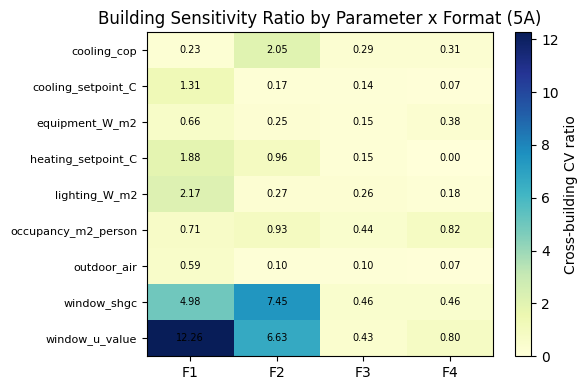

Correlation (building-sensitivity ratio, midpoint-stickiness rate), F3/F4: -0.491


In [51]:
# S5K — Building sensitivity (K5): ratio of the LLM output's cross-building
# CV to the DOE reference's cross-building CV. Cross-checked against
# midpoint-stickiness (S5J) for F3/F4, since a per-building LOBO range
# alone can induce building differentiation without independent estimation.
def cv(x):
    x = np.asarray(x, dtype=float)
    return x.std() / x.mean() if x.mean() != 0 else np.nan

ref_cv = ref_long.groupby('true_name')['ref_value'].apply(cv)

sensitivity_rows = []
for (fmt, param), g in gso_df.groupby(['format', 'true_name']):
    building_means = g.groupby('building')['value'].mean()
    llm_cv = cv(building_means.values)
    r_cv = ref_cv.get(param, np.nan)
    ratio = llm_cv / r_cv if r_cv else np.nan
    sensitivity_rows.append({'format': fmt, 'parameter': param, 'llm_cv': llm_cv,
                              'ref_cv': r_cv, 'ratio': ratio,
                              'building_sensitive': ratio > 0.5 if pd.notna(ratio) else None})

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(f'{S5_DIR}/building_sensitivity.csv', index=False)
print(sensitivity_df.groupby('format')['building_sensitive'].sum().to_string())

pivot3 = sensitivity_df.pivot(index='parameter', columns='format', values='ratio').reindex(columns=['F1', 'F2', 'F3', 'F4'])
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot3, cmap='YlGnBu', aspect='auto', vmin=0)
ax.set_xticks(range(4)); ax.set_xticklabels(pivot3.columns)
ax.set_yticks(range(len(pivot3))); ax.set_yticklabels(pivot3.index, fontsize=8)
for i in range(len(pivot3)):
    for j in range(4):
        v = pivot3.iloc[i, j]
        ax.text(j, i, f'{v:.2f}' if pd.notna(v) else '-', ha='center', va='center', fontsize=7)
plt.colorbar(im, label='Cross-building CV ratio')
plt.title('Building Sensitivity Ratio by Parameter x Format (5A)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/building_sensitivity.png', dpi=200)
plt.show()

midpoint_rate = (midpoint_df.groupby(['format', 'true_name'])['midpoint_sticky'].mean()
                  .rename('midpoint_sticky_rate').reset_index()
                  .rename(columns={'true_name': 'parameter'}))
k5_crosscheck = sensitivity_df[sensitivity_df.format.isin(['F3', 'F4'])].merge(
    midpoint_rate, on=['format', 'parameter'], how='left')
k5_crosscheck.to_csv(f'{S5_DIR}/K5_building_sensitivity_crosscheck.csv', index=False)
k5_corr = k5_crosscheck[['ratio', 'midpoint_sticky_rate']].corr().iloc[0, 1]
print(f'Correlation (building-sensitivity ratio, midpoint-stickiness rate), F3/F4: {k5_corr:.3f}')

In [52]:
# S5L — Climate x Method: parameter-level GSO by climate (available for
# F4 and both baselines, simulated at all three climates). Energy-level
# CV(RMSE)/EYA by climate is not computable (no DOE reference at 1A/7).
f4_all_climates = param_debug[(param_debug.format == 'F4')].merge(ref_long, on=['building', 'true_name'], how='left')
f4_all_climates['gso_pct'] = (f4_all_climates['value'] - f4_all_climates['ref_value']).abs() / f4_all_climates['ref_value'].abs() * 100

baseline_all_climates = all_vectors[all_vectors.source_type == 'deterministic_baseline'].melt(
    id_vars=['building', 'climate', 'source'], value_vars=TARGET_PARAMS, var_name='true_name', value_name='value')
baseline_all_climates = baseline_all_climates.merge(ref_long, on=['building', 'true_name'], how='left')
baseline_all_climates['gso_pct'] = (baseline_all_climates['value'] - baseline_all_climates['ref_value']).abs() / baseline_all_climates['ref_value'].abs() * 100

climate_method_gso = pd.concat([
    f4_all_climates.groupby(['model', 'climate'])['gso_pct'].median().rename('gso_pct').reset_index()
        .rename(columns={'model': 'method'}).assign(method=lambda d: 'F4_' + d['method']),
    baseline_all_climates.groupby(['source', 'climate'])['gso_pct'].median().reset_index()
        .rename(columns={'source': 'method'}),
])
climate_method_pivot = climate_method_gso.pivot(index='method', columns='climate', values='gso_pct')
climate_method_pivot.to_csv(f'{S5_DIR}/climate_method_interaction_gso.csv')
print(climate_method_pivot.round(2).to_string())

climate                        1A     5A      7
method                                         
F4_llama-3.3-70b-versatile  14.13  14.13  11.88
F4_openai/gpt-oss-120b      18.80  18.45  18.69
global_constant              5.55   5.55   5.55
lobo_median_loo              4.68   4.68   4.68


In [53]:
# S5M — Benjamini-Hochberg FDR correction, single pooled family across all
# GSO comparisons and both K4 (energy, GSO) ANOVA terms.
pvalue_rows = []
for fmt in ['F2', 'F3', 'F4']:
    a = gso_df[gso_df.format == 'F1']['gso_pct'].dropna()
    b = gso_df[gso_df.format == fmt]['gso_pct'].dropna()
    _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    pvalue_rows.append({'comparison': f'GSO F1 vs {fmt}', 'p_raw': p})

for method in ['lobo_median_loo', 'global_constant', 'uniform_random']:
    a = gso_df[gso_df.format == 'F4']['gso_pct'].dropna()
    b = (baseline_gso[baseline_gso.baseline_type == method]['gso_pct'].dropna()
         if method != 'uniform_random' else ur_long['gso_pct'].dropna())
    _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    pvalue_rows.append({'comparison': f'GSO F4 vs {method}', 'p_raw': p})

a = gso_df[gso_df.format == 'F4']['gso_pct'].dropna()
_, p = stats.mannwhitneyu(a, midpoint_baseline_df['gso_pct'].dropna(), alternative='two-sided')
pvalue_rows.append({'comparison': 'GSO F4 vs range_midpoint', 'p_raw': p})

for term in anova_table.index:
    if term != 'Residual':
        pvalue_rows.append({'comparison': f'K4-energy ANOVA: {term}', 'p_raw': anova_table.loc[term, 'PR(>F)']})
for term in anova_gso_table.index:
    if term != 'Residual':
        pvalue_rows.append({'comparison': f'K4-GSO ANOVA: {term}', 'p_raw': anova_gso_table.loc[term, 'PR(>F)']})

pval_df = pd.DataFrame(pvalue_rows).dropna(subset=['p_raw'])
reject, p_adj, _, _ = multipletests(pval_df['p_raw'], alpha=0.05, method='fdr_bh')
pval_df['p_fdr'] = p_adj
pval_df['reject_fdr'] = reject
pval_df.to_csv(f'{S5_DIR}/fdr_correction.csv', index=False)
print(f'{len(pval_df)} tests, FDR-corrected:')
print(pval_df.round(5).to_string(index=False))

17 tests, FDR-corrected:
                       comparison   p_raw   p_fdr  reject_fdr
                     GSO F1 vs F2 0.00000 0.00000        True
                     GSO F1 vs F3 0.00000 0.00000        True
                     GSO F1 vs F4 0.00000 0.00000        True
        GSO F4 vs lobo_median_loo 0.00565 0.00686        True
        GSO F4 vs global_constant 0.00501 0.00655        True
         GSO F4 vs uniform_random 0.00020 0.00028        True
         GSO F4 vs range_midpoint 0.08743 0.09909       False
         K4-energy ANOVA: C(Unit) 0.00000 0.00000        True
        K4-energy ANOVA: C(Range) 0.00000 0.00000        True
     K4-energy ANOVA: C(building) 0.00000 0.00000        True
        K4-energy ANOVA: C(model) 0.74994 0.74994       False
K4-energy ANOVA: C(Unit):C(Range) 0.00000 0.00000        True
            K4-GSO ANOVA: C(Unit) 0.00000 0.00000        True
           K4-GSO ANOVA: C(Range) 0.00000 0.00000        True
        K4-GSO ANOVA: C(building) 0.18840 0.2

In [54]:
# S5N — Environment record, Sprint 5 extended (S5I-M).
summary_ext = {
    'sprint': 'Sprint 5 extended: STI, K5 sensitivity + crosscheck, midpoint, climate x method, FDR',
    'n_sti_gso_triples': len(sti_gso), 'n_sensitivity_rows': len(sensitivity_df),
    'k5_crosscheck_correlation': float(k5_corr),
    'n_midpoint_rows': len(midpoint_df), 'n_fdr_tests': len(pval_df),
    'climate_method_energy_level': 'blocked -- no DOE reference at 1A/7',
    'k4_gso_vs_range_midpoint_p_fdr': float(pval_df.loc[pval_df.comparison == 'GSO F4 vs range_midpoint', 'p_fdr'].iloc[0]),
}
with open(f'{DATA}/environment_sprint5b.json', 'w') as f:
    json.dump(summary_ext, f, indent=2, default=str)
print(json.dumps(summary_ext, indent=2, default=str))

{
  "sprint": "Sprint 5 extended: STI, K5 sensitivity + crosscheck, midpoint, climate x method, FDR",
  "n_sti_gso_triples": 360,
  "n_sensitivity_rows": 36,
  "k5_crosscheck_correlation": -0.4911910392274207,
  "n_midpoint_rows": 900,
  "n_fdr_tests": 17,
  "climate_method_energy_level": "blocked -- no DOE reference at 1A/7",
  "k4_gso_vs_range_midpoint_p_fdr": 0.09909127607826103
}


# Sprint 5 — Evaluation Metrics and Statistical Modeling

Computes all core evaluation metrics from Sprint 4's simulation outputs and
fits the study's two primary statistical models.

**Metrics:** K1 (GSO, parameter-level offset), K2 (CV(RMSE)/NMBE vs. DOE
reference, ASHRAE-14 monthly), K3 (EYA energy-ratio anomaly on total
electricity+gas energy, and PFI physical-bound violations), K4 (Unit×Range
fixed-effects ANOVA, fit separately at the energy level and the
parameter level).

**Baselines:** LOBO-median, global-constant, and uniform-random are
compared against all four prompt formats at both metric levels; the
range midpoint is added as an analytic (non-simulated) parameter-level
baseline only.

**Extended analyses (S5I–N):** cross-seed Stochasticity Index, K5 building
sensitivity with an independent midpoint-stickiness crosscheck, climate ×
method interaction, and a single pooled Benjamini–Hochberg FDR correction
across all 17 hypothesis tests reported in this and the following sprint.

**Reproducibility:** `environment_sprint5.json` and `environment_sprint5b.json`
record the row counts, formulas, and key statistics for the
Reproducibility Audit consumed in Sprint 6.